# CS461 讽刺检测项目

这个笔记本用于所有实验：数据探索、模型训练、评估

**流程**：
1. 数据探索
2. 训练基线模型（逻辑回归 + TF-IDF）
3. 尝试进阶模型（SVM、LSTM等）
4. 保存最佳模型
5. 记录所有结果（用于报告）


## 第一步：加载库和数据


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(valid_df)} samples")
print(f"Test set: {len(test_df)} samples")

# 查看前几行
train_df.head()


Training set: 21464 samples
Validation set: 716 samples
Test set: 966 samples


,text,label
0,states slow to shut down weak teacher educatio...,0
1,drone places fresh kill on steps of white house,1
2,report: majority of instances of people gettin...,1
3,"sole remaining lung filled with rich, satisfyi...",1
4,the gop's stockholm syndrome,0


Label Distribution:
label
0    11248
1    10216
Name: count, dtype: int64

Sarcasm ratio: 47.60%


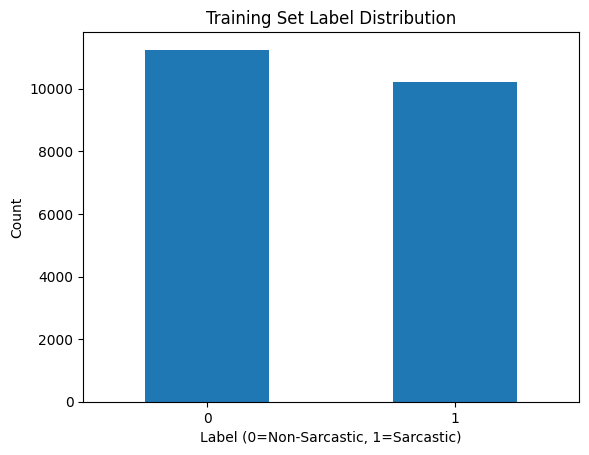


Average text length: 62.3 characters

Sarcastic examples:
  - drone places fresh kill on steps of white house
  - report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
  - sole remaining lung filled with rich, satisfying flavor

Non-sarcastic examples:
  - states slow to shut down weak teacher education programs
  - the gop's stockholm syndrome
  - trump's game plan


In [4]:
# 标签分布
print("Label Distribution:")
print(train_df['label'].value_counts())
print(f"\nSarcasm ratio: {train_df['label'].mean()*100:.2f}%")

# 可视化
train_df['label'].value_counts().plot(kind='bar')
plt.title('Training Set Label Distribution')
plt.xlabel('Label (0=Non-Sarcastic, 1=Sarcastic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 文本长度
train_df['length'] = train_df['text'].str.len()
print(f"\nAverage text length: {train_df['length'].mean():.1f} characters")

# 查看样例
print("\nSarcastic examples:")
for text in train_df[train_df['label']==1]['text'].head(3):
    print(f"  - {text}")
    
print("\nNon-sarcastic examples:")
for text in train_df[train_df['label']==0]['text'].head(3):
    print(f"  - {text}")


## 第三步：训练基线模型 - 逻辑回归 + TF-IDF

目标：F1 > 0.70


In [5]:
# 简单预处理：转小写
train_texts = train_df['text'].str.lower()
valid_texts = valid_df['text'].str.lower()
test_texts = test_df['text'].str.lower()

# TF-IDF特征提取
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test = vectorizer.transform(test_texts)

print(f"Feature dimension: {X_train.shape[1]}")

# 训练逻辑回归
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_df['label'])

# 验证集评估
y_pred_valid = model.predict(X_valid)
print("\nValidation Set Performance:")
print(classification_report(valid_df['label'], y_pred_valid))
print(f"F1 Score: {f1_score(valid_df['label'], y_pred_valid):.4f}")

# 测试集评估
y_pred_test = model.predict(X_test)
print("\nTest Set Performance:")
print(classification_report(test_df['label'], y_pred_test))
print(f"Accuracy:  {accuracy_score(test_df['label'], y_pred_test):.4f}")
print(f"F1 Score:  {f1_score(test_df['label'], y_pred_test):.4f}")


Feature dimension: 5000

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       360
           1       0.83      0.83      0.83       356

    accuracy                           0.83       716
   macro avg       0.83      0.83      0.83       716
weighted avg       0.83      0.83      0.83       716

F1 Score: 0.8315

Test Set Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       526
           1       0.81      0.82      0.82       440

    accuracy                           0.83       966
   macro avg       0.83      0.83      0.83       966
weighted avg       0.83      0.83      0.83       966

Accuracy:  0.8323
F1 Score:  0.8163



Confusion Matrix (Test Set):
[[444  82]
 [ 80 360]]

True Negative (TN): 444 | False Positive (FP): 82
False Negative (FN): 80 | True Positive (TP): 360


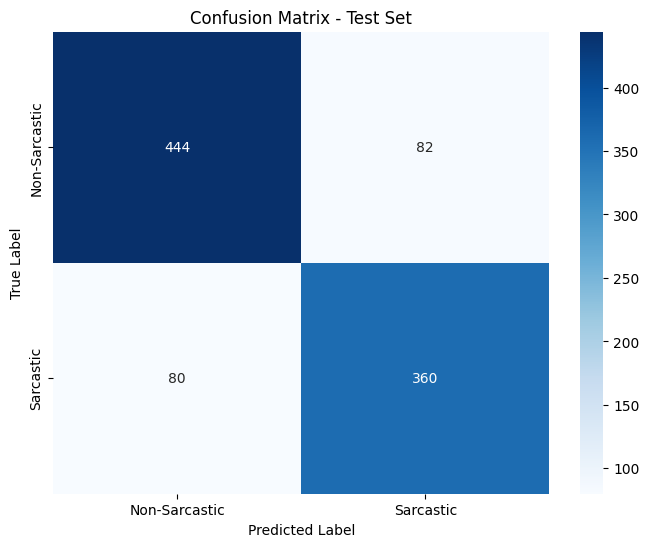


✅ Manual Verification:
Accuracy: 0.8323
Precision (Sarcastic class): 0.8145
Recall (Sarcastic class): 0.8182
F1 (Sarcastic class): 0.8163


In [6]:
# 验证：查看混淆矩阵
from sklearn.metrics import confusion_matrix

# 测试集混淆矩阵
cm = confusion_matrix(test_df['label'], y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTrue Negative (TN): {cm[0,0]} | False Positive (FP): {cm[0,1]}")
print(f"False Negative (FN): {cm[1,0]} | True Positive (TP): {cm[1,1]}")

# 可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 计算详细指标
print("\n✅ Manual Verification:")
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_class1 = tp / (tp + fp)
recall_class1 = tp / (tp + fn)
f1_class1 = 2 * (precision_class1 * recall_class1) / (precision_class1 + recall_class1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Sarcastic class): {precision_class1:.4f}")
print(f"Recall (Sarcastic class): {recall_class1:.4f}")
print(f"F1 (Sarcastic class): {f1_class1:.4f}")


## 第四步：保存模型

保存最佳模型用于最终提交


In [ ]:
import joblib

# 保存模型和向量化器
joblib.dump(model, 'models/model_weights.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("✅ Model saved to models/ folder")


---

## 🔄 下一步改进方向

在下面添加新的代码单元格尝试：

1. **更多模型**：
   - SVM
   - Random Forest
   - Naive Bayes
   
2. **更好的特征**：
   - Word2Vec / GloVe
   - 不同的n-gram组合
   - 手工特征（标点、大写等）

3. **深度学习**：
   - LSTM
   - BiLSTM
   - CNN

4. **集成方法**：
   - 投票集成
   - Stacking

记得记录所有实验结果用于报告！


---

## 📊 结果记录（用于报告）


In [8]:
# 实验结果记录（复制到报告）
results = {
    'Model': 'Logistic Regression + TF-IDF',
    'Features': 'unigram + bigram, max_features=5000',
    'Preprocessing': 'lowercase',
    'Validation F1': f"{f1_score(valid_df['label'], y_pred_valid):.4f}",
    'Test Accuracy': f"{accuracy_score(test_df['label'], y_pred_test):.4f}",
    'Test Precision': f"{precision_class1:.4f}",
    'Test Recall': f"{recall_class1:.4f}",
    'Test F1': f"{f1_class1:.4f}"
}

print("="*60)
print("BASELINE MODEL RESULTS (For Report)")
print("="*60)
for key, value in results.items():
    print(f"{key:20s}: {value}")
print("="*60)


BASELINE MODEL RESULTS (For Report)
Model               : Logistic Regression + TF-IDF
Features            : unigram + bigram, max_features=5000
Preprocessing       : lowercase
Validation F1       : 0.8315
Test Accuracy       : 0.8323
Test Precision      : 0.8145
Test Recall         : 0.8182
Test F1             : 0.8163


---

## 🔧 超参数调优实验


In [9]:
# 方法1：手动尝试不同参数组合
from sklearn.metrics import f1_score
import time

# 定义要测试的参数组合
experiments = [
    # 实验1: 增加特征数量
    {'name': 'More Features', 
     'vectorizer': TfidfVectorizer(max_features=10000, ngram_range=(1,2)),
     'model': LogisticRegression(max_iter=1000, random_state=42)},
    
    # 实验2: 添加trigram
    {'name': 'Trigram', 
     'vectorizer': TfidfVectorizer(max_features=5000, ngram_range=(1,3)),
     'model': LogisticRegression(max_iter=1000, random_state=42)},
    
    # 实验3: 更强的正则化
    {'name': 'Stronger Regularization', 
     'vectorizer': TfidfVectorizer(max_features=5000, ngram_range=(1,2)),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=0.5)},
    
    # 实验4: 添加过滤和缩放
    {'name': 'With min_df & sublinear_tf', 
     'vectorizer': TfidfVectorizer(max_features=7000, ngram_range=(1,2), min_df=3, sublinear_tf=True),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=1.0)},
    
    # 实验5: 组合优化
    {'name': 'Combined Optimization', 
     'vectorizer': TfidfVectorizer(max_features=8000, ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True),
     'model': LogisticRegression(max_iter=1000, random_state=42, C=2.0)},
]

# 运行所有实验
print("="*80)
print("HYPERPARAMETER TUNING EXPERIMENTS")
print("="*80)

results_list = []

for exp in experiments:
    start_time = time.time()
    
    # 特征提取
    vec = exp['vectorizer']
    X_train_exp = vec.fit_transform(train_texts)
    X_valid_exp = vec.transform(valid_texts)
    X_test_exp = vec.transform(test_texts)
    
    # 训练
    mdl = exp['model']
    mdl.fit(X_train_exp, train_df['label'])
    
    # 评估
    y_pred_valid_exp = mdl.predict(X_valid_exp)
    y_pred_test_exp = mdl.predict(X_test_exp)
    
    valid_f1 = f1_score(valid_df['label'], y_pred_valid_exp)
    test_f1 = f1_score(test_df['label'], y_pred_test_exp)
    test_acc = accuracy_score(test_df['label'], y_pred_test_exp)
    
    elapsed = time.time() - start_time
    
    # 记录结果
    results_list.append({
        'Experiment': exp['name'],
        'Valid F1': valid_f1,
        'Test F1': test_f1,
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })
    
    print(f"\n{exp['name']:35s} | Valid F1: {valid_f1:.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc:.4f} | Time: {elapsed:.1f}s")

print("\n" + "="*80)
print("SUMMARY - Sorted by Test F1")
print("="*80)

# 转换为DataFrame并排序
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Test F1', ascending=False)
print(results_df.to_string(index=False))

# 找出最佳配置
best_exp = results_df.iloc[0]
print(f"\n🏆 Best Configuration: {best_exp['Experiment']}")
print(f"   Test F1: {best_exp['Test F1']:.4f}")
print(f"   Improvement: {(best_exp['Test F1'] - 0.8163)*100:.2f} percentage points")


HYPERPARAMETER TUNING EXPERIMENTS

More Features                       | Valid F1: 0.8305 | Test F1: 0.8318 | Test Acc: 0.8468 | Time: 0.4s

Trigram                             | Valid F1: 0.8315 | Test F1: 0.8127 | Test Acc: 0.8292 | Time: 0.6s

Stronger Regularization             | Valid F1: 0.8280 | Test F1: 0.8157 | Test Acc: 0.8302 | Time: 0.3s

With min_df & sublinear_tf          | Valid F1: 0.8300 | Test F1: 0.8202 | Test Acc: 0.8375 | Time: 0.4s

Combined Optimization               | Valid F1: 0.8315 | Test F1: 0.8285 | Test Acc: 0.8458 | Time: 0.6s

SUMMARY - Sorted by Test F1
                Experiment  Valid F1  Test F1  Test Acc  Time (s)
             More Features  0.830508 0.831818  0.846791  0.352068
     Combined Optimization  0.831461 0.828539  0.845756  0.616205
With min_df & sublinear_tf  0.830028 0.820160  0.837474  0.350285
   Stronger Regularization  0.827972 0.815730  0.830228  0.324972
                   Trigram  0.831461 0.812713  0.829193  0.622573

🏆 Best Con

### 方法2：使用GridSearchCV自动搜索最佳参数（更系统）


In [10]:
# 使用GridSearchCV进行自动调优（可选，会比较慢）
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 创建Pipeline（把特征提取和模型训练串联）
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 定义参数网格
param_grid = {
    # TF-IDF参数
    'tfidf__max_features': [5000, 7000, 10000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'tfidf__min_df': [2, 3],
    'tfidf__sublinear_tf': [True, False],
    
    # 逻辑回归参数
    'clf__C': [0.5, 1.0, 2.0],
}

# 创建GridSearchCV
print("Starting Grid Search... (This may take 5-10 minutes)")
print(f"Total combinations to test: {3 * 2 * 2 * 2 * 3} = 72")

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,                    # 5折交叉验证
    scoring='f1',            # 优化F1分数
    n_jobs=-1,               # 使用所有CPU核心
    verbose=1                # 显示进度
)

# 在训练集上搜索
grid_search.fit(train_texts, train_df['label'])

# 显示最佳参数
print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:30s}: {value}")

print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")

# 在测试集上评估
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(test_texts)
test_f1_grid = f1_score(test_df['label'], y_pred_test_grid)
test_acc_grid = accuracy_score(test_df['label'], y_pred_test_grid)

print(f"\nTest Set Performance with Best Model:")
print(f"  F1 Score:  {test_f1_grid:.4f}")
print(f"  Accuracy:  {test_acc_grid:.4f}")
print(f"  Improvement over baseline: {(test_f1_grid - 0.8163)*100:.2f} percentage points")


Starting Grid Search... (This may take 5-10 minutes)
Total combinations to test: 72 = 72
Fitting 5 folds for each of 72 candidates, totalling 360 fits

GRID SEARCH RESULTS

Best parameters found:
  clf__C                        : 2.0
  tfidf__max_features           : 10000
  tfidf__min_df                 : 3
  tfidf__ngram_range            : (1, 2)
  tfidf__sublinear_tf           : False

Best cross-validation F1 score: 0.8354

Test Set Performance with Best Model:
  F1 Score:  0.8311
  Accuracy:  0.8468
  Improvement over baseline: 1.48 percentage points
